In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_gpus = 1 if device=='cuda' else 0
print(device)

cuda


In [2]:
import numpy as np
from pathlib import Path

base = Path("RDP_exp_data/mnist_lr_eps_8.0_a_2.0_dataset_100")

losses_in  = np.load(base / "losses_in.npy")     # shape depends on how you saved it
losses_out = np.load(base / "losses_out.npy")

print("losses_in:", losses_in.shape, losses_in.dtype)
print("losses_out:", losses_out.shape, losses_out.dtype)
print(losses_in)
print(losses_out)


losses_in: (50000,) float32
losses_out: (50000,) float32
[-4.07696   -4.160248  -4.5075445 ... -3.74652   -4.2203007 -3.8784308]
[-4.435562  -4.7048306 -4.41618   ... -5.167106  -6.318206  -4.942835 ]


In [3]:
class LoadDataset(torch.utils.data.Dataset):
    def __init__(self, N, x, y, x_dim, z_dim):
        self.x = x
        self.y = y
        # file imports and object initialization
        
        self.N = N
        self.x_dim = x_dim
        self.z_dim = z_dim

    def __getitem__(self, ix):
        a, b = self.x[ix,0:self.x_dim], self.y[ix,0:self.z_dim]
        
        return a, b
    
    def __len__(self):
        return self.N

In [4]:
%reload_ext autoreload
from renyi import RenyiDivergenceEstimator
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import TQDMProgressBar

x_dim = 1 #plaintext length of a single sample
z_dim = 1 #ciphertext length of a single sample
N = 49999 # num samples -1
lr = 1e-4 #learning rate
epochs = 10 #epochs
batch_size = 5000 #batch size
Renyi_order = 2
accelerator = "gpu" if torch.cuda.is_available() else "cpu"
devices = 1  # one device either way

from pytorch_lightning.loggers import CSVLogger

csv_logger = CSVLogger("lightning_logs", name="renyi_run")

#format data
loss_type = ['mine']
# X, Y already constructed as tensors of shape (N, 1)
X = torch.tensor(losses_in,  dtype=torch.float32).view(-1, 1)
Y = torch.tensor(losses_out, dtype=torch.float32).view(-1, 1)
N = min(len(X), len(Y))
X, Y = X[:N], Y[:N]  # ensure same length

# --- 80/20 split: first 80% train, last 20% test ---
n_train = int(0.8 * N)
X_train, Y_train = X[:n_train], Y[:n_train]
X_test,  Y_test  = X[n_train:], Y[n_train:]

train_loader = torch.utils.data.DataLoader(
    LoadDataset(len(X_train), X_train, Y_train, x_dim=1, z_dim=1),
    batch_size=batch_size,
    shuffle=True,      # ok to shuffle *within* the training set
    drop_last=False
)

test_loader = torch.utils.data.DataLoader(
    LoadDataset(len(X_test), X_test, Y_test, x_dim=1, z_dim=1),
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)



trainer = Trainer(
    max_epochs=epochs,
    accelerator=accelerator,
    devices=devices,
    logger=csv_logger,
    enable_checkpointing=False,
    enable_progress_bar=True,
    callbacks=[TQDMProgressBar(refresh_rate=10)],
    log_every_n_steps=10,
)
model = RenyiDivergenceEstimator(
    lr=lr,
    renyi_order=Renyi_order,
    ema_rate=0.25,   # your EMA rate (beta)
    hidden=100,
)


trainer.fit(model, train_dataloaders=train_loader)
results = trainer.test(model, dataloaders=test_loader)

print("DV-Rényi lower bound (epoch-avg):", results[0]["test_renyi_lb"])
print("Same value from model:", model.avg_test_renyi_lb)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4]


Device: cuda


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ T           │ T     │ 10.4 K │ train │     0 │
│ 1 │ energy_loss │ Renyi │ 10.4 K │ train │     0 │
└───┴─────────────┴───────┴────────┴───────┴───────┘

Trainable params: 10.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Epoch 9: 100%|██████████| 8/8 [00:00<00:00, 14.55it/s, v_num=16, train_loss_step=-0.542, train_renyi_lb_step=0.542, train_loss_epoch=-0.516, train_renyi_lb_epoch=0.516]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4]
/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.



Testing DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 43.80it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    -0.5563209056854248    │
│       test_renyi_lb       │    0.5563209056854248     │
└───────────────────────────┴───────────────────────────┘

DV-Rényi lower bound (epoch-avg): 0.5563209056854248
Same value from model: 0.5563209056854248


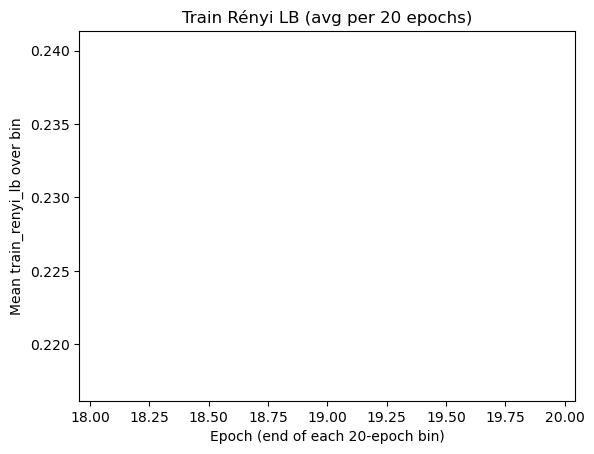

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

metrics_path = os.path.join(csv_logger.log_dir, "metrics.csv")
df = pd.read_csv(metrics_path)

# Lightning writes multiple rows; keep only rows where the epoch-aggregated metric exists
# (column name is typically train_renyi_lb_epoch because you logged on_epoch=True)
epoch_df = df[["epoch", "train_renyi_lb_epoch"]].dropna()

# If there are multiple rows per epoch, keep the last one per epoch
epoch_df = epoch_df.groupby("epoch", as_index=False).last()

# Bin epochs into groups of 20 and average within each bin
epoch_df["bin"] = (epoch_df["epoch"] // 20).astype(int)
avg20 = epoch_df.groupby("bin", as_index=False)["train_renyi_lb_epoch"].mean()
avg20["epoch_end"] = avg20["bin"] * 20 + 19  # label each point by the ending epoch in the bin

plt.figure()
plt.plot(avg20["epoch_end"], avg20["train_renyi_lb_epoch"])
plt.xlabel("Epoch (end of each 20-epoch bin)")
plt.ylabel("Mean train_renyi_lb over bin")
plt.title("Train Rényi LB (avg per 20 epochs)")
plt.show()


In [6]:
import numpy as np
import math

Renyi_order = 2.0
# -------------------------
# Utilities
# -------------------------
def _to_1d_finite(x):
    x = np.asarray(x).reshape(-1).astype(np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        raise ValueError("No finite samples after filtering NaN/Inf.")
    return x

def logmeanexp(a):
    a = np.asarray(a, dtype=np.float64)
    m = np.max(a)
    return m + np.log(np.mean(np.exp(a - m)))

# -------------------------
# Gaussian MLE fit + logpdf
# -------------------------
def fit_gaussian_mle(x, var_floor=1e-12):
    x = _to_1d_finite(x)
    mu = float(np.mean(x))
    var = float(np.mean((x - mu) ** 2))  # MLE (divide by n)
    var = max(var, var_floor)
    return mu, var

def logpdf_gaussian(x, mu, var):
    x = np.asarray(x, dtype=np.float64)
    return -0.5 * (np.log(2.0 * np.pi * var) + (x - mu) ** 2 / var)

# -------------------------
# Rényi divergence estimators
#   D_alpha(Q||P) = 1/(alpha-1) * log ∫ q(x)^alpha p(x)^(1-alpha) dx
# -------------------------
def renyi_gaussian_closed_form(mu_q, var_q, mu_p, var_p, alpha):
    """
    Closed-form for 1D Gaussian q=N(mu_q,var_q), p=N(mu_p,var_p).
    Returns +inf if the integral diverges (can happen for alpha>1 if p is too "narrow").
    """
    a = float(alpha)
    if a <= 1.0:
        raise ValueError("alpha must be > 1")

    # Derived by completing the square in the exponent:
    # A = a/var_q - (a-1)/var_p must be > 0 for finiteness.
    A = a / var_q - (a - 1.0) / var_p
    if A <= 0:
        return float("inf")

    B = a * mu_q / var_q - (a - 1.0) * mu_p / var_p
    C = a * (mu_q ** 2) / var_q - (a - 1.0) * (mu_p ** 2) / var_p

    # log I where I = ∫ q^a p^(1-a)
    logI = (
        -0.5 * a * np.log(var_q)
        -0.5 * (1.0 - a) * np.log(var_p)
        -0.5 * np.log(A)
        -0.5 * (C - (B * B) / A)
    )
    return float(logI / (a - 1.0))

def renyi_gaussian_mle_closed(q_samples, p_samples, alpha):
    mu_q, var_q = fit_gaussian_mle(q_samples)
    mu_p, var_p = fit_gaussian_mle(p_samples)
    D = renyi_gaussian_closed_form(mu_q, var_q, mu_p, var_p, alpha)
    return D, (mu_q, var_q, mu_p, var_p)

def renyi_gaussian_mle_mc(q_samples, p_samples, alpha):
    """
    MLE-fit Gaussians to Q and P, then estimate:
      D_alpha(Q||P) = (1/(a-1)) log E_{X~P}[ (q(X)/p(X))^a ]
    using X as your *empirical* p_samples (MC under P).
    """
    a = float(alpha)
    if a <= 1.0:
        raise ValueError("alpha must be > 1")

    q = _to_1d_finite(q_samples)
    p = _to_1d_finite(p_samples)

    mu_q, var_q = fit_gaussian_mle(q)
    mu_p, var_p = fit_gaussian_mle(p)

    log_q = logpdf_gaussian(p, mu_q, var_q)
    log_p = logpdf_gaussian(p, mu_p, var_p)

    # log w_i = a*(log q(x_i) - log p(x_i))
    logw = a * (log_q - log_p)
    logE = logmeanexp(logw)  # log E_P[(q/p)^a]
    return float(logE / (a - 1.0)), (mu_q, var_q, mu_p, var_p)

# -------------------------
# Optional: GMM MLE + MC (if sklearn is available)
# -------------------------
def renyi_gmm_mle_mc(q_samples, p_samples, alpha, n_components=3, reg_covar=1e-6, seed=0):
    """
    Fits separate 1D GMMs to Q and P by EM (sklearn), then uses empirical P samples for MC:
      D_alpha(Q||P) = (1/(a-1)) log E_{X~P}[ (q_hat(X)/p_hat(X))^a ].
    """
    a = float(alpha)
    if a <= 1.0:
        raise ValueError("alpha must be > 1")

    q = _to_1d_finite(q_samples).reshape(-1, 1)
    p = _to_1d_finite(p_samples).reshape(-1, 1)

    try:
        from sklearn.mixture import GaussianMixture
    except Exception as e:
        raise ImportError("scikit-learn not available; install or skip GMM.") from e

    gq = GaussianMixture(n_components=n_components, reg_covar=reg_covar, random_state=seed)
    gp = GaussianMixture(n_components=n_components, reg_covar=reg_covar, random_state=seed)
    gq.fit(q)
    gp.fit(p)

    # score_samples gives log density
    log_q = gq.score_samples(p)
    log_p = gp.score_samples(p)

    logw = a * (log_q - log_p)
    logE = logmeanexp(logw)
    return float(logE / (a - 1.0))

# -------------------------
# Optional: bootstrap CI (rough)
# -------------------------
def bootstrap_ci(estimator_fn, q_samples, p_samples, alpha, B=200, seed=0):
    q = _to_1d_finite(q_samples)
    p = _to_1d_finite(p_samples)
    rng = np.random.default_rng(seed)

    n_q, n_p = len(q), len(p)
    ests = np.empty(B, dtype=np.float64)
    for b in range(B):
        qb = q[rng.integers(0, n_q, size=n_q)]
        pb = p[rng.integers(0, n_p, size=n_p)]
        ests[b] = estimator_fn(qb, pb, alpha)[0] if isinstance(estimator_fn(qb, pb, alpha), tuple) else estimator_fn(qb, pb, alpha)

    est = float(np.mean(ests))
    lo, hi = np.quantile(ests, [0.025, 0.975])
    return est, (float(lo), float(hi))

# -------------------------
# Run on your arrays
# -------------------------
alpha = float(Renyi_order)  # e.g., 2.0

Q = losses_in   # treat as Q samples
P = losses_out  # treat as P samples

D_gauss_closed, params = renyi_gaussian_mle_closed(Q, P, alpha)
D_gauss_mc,     params2 = renyi_gaussian_mle_mc(Q, P, alpha)

print("\n=== Gaussian MLE results ===")
print("params (mu_q, var_q, mu_p, var_p):", params)
print(f"D_{alpha}(Q||P) Gaussian closed-form  : {D_gauss_closed:.6f}")
print(f"D_{alpha}(Q||P) Gaussian MLE + MC      : {D_gauss_mc:.6f}")

# Optional: GMM
try:
    D_gmm_mc = renyi_gmm_mle_mc(Q, P, alpha, n_components=3)
    print("\n=== GMM(3) MLE + MC ===")
    print(f"D_{alpha}(Q||P) GMM(3) MLE + MC        : {D_gmm_mc:.6f}")
except ImportError as e:
    print("\n(skipping GMM; scikit-learn not available)")

# Optional: bootstrap CI (on Gaussian closed-form plug-in)
est_mean, (ci_lo, ci_hi) = bootstrap_ci(renyi_gaussian_mle_closed, Q, P, alpha, B=200, seed=0)
print("\n=== Rough bootstrap (Gaussian plug-in) ===")
print(f"bootstrap mean: {est_mean:.6f}  95% CI: [{ci_lo:.6f}, {ci_hi:.6f}]")



alpha = float(Renyi_order)  # e.g., 2.0

Q = losses_out   # treat as Q samples
P = losses_in  # treat as P samples

D_gauss_closed, params = renyi_gaussian_mle_closed(Q, P, alpha)
D_gauss_mc,     params2 = renyi_gaussian_mle_mc(Q, P, alpha)

print("\n=== Gaussian MLE results ===")
print("params (mu_q, var_q, mu_p, var_p):", params)
print(f"D_{alpha}(P||Q) Gaussian closed-form  : {D_gauss_closed:.6f}")
print(f"D_{alpha}(P||Q) Gaussian MLE + MC      : {D_gauss_mc:.6f}")

# Optional: GMM
try:
    D_gmm_mc = renyi_gmm_mle_mc(Q, P, alpha, n_components=3)
    print("\n=== GMM(3) MLE + MC ===")
    print(f"D_{alpha}(P||Q) GMM(3) MLE + MC        : {D_gmm_mc:.6f}")
except ImportError as e:
    print("\n(skipping GMM; scikit-learn not available)")

# Optional: bootstrap CI (on Gaussian closed-form plug-in)
est_mean, (ci_lo, ci_hi) = bootstrap_ci(renyi_gaussian_mle_closed, Q, P, alpha, B=200, seed=0)
print("\n=== Rough bootstrap (Gaussian plug-in) ===")
print(f"bootstrap mean: {est_mean:.6f}  95% CI: [{ci_lo:.6f}, {ci_hi:.6f}]")


=== Gaussian MLE results ===
params (mu_q, var_q, mu_p, var_p): (-3.7822916554880144, 0.20745735940376347, -4.991584556355477, 0.21869609678988391)
D_2.0(Q||P) Gaussian closed-form  : 6.361339
D_2.0(Q||P) Gaussian MLE + MC      : 5.604859

=== GMM(3) MLE + MC ===
D_2.0(Q||P) GMM(3) MLE + MC        : 11.829552

=== Rough bootstrap (Gaussian plug-in) ===
bootstrap mean: 6.363595  95% CI: [6.188413, 6.518249]

=== Gaussian MLE results ===
params (mu_q, var_q, mu_p, var_p): (-4.991584556355477, 0.21869609678988391, -3.7822916554880144, 0.20745735940376347)
D_2.0(P||Q) Gaussian closed-form  : 7.454326
D_2.0(P||Q) Gaussian MLE + MC      : 7.606316

=== GMM(3) MLE + MC ===
D_2.0(P||Q) GMM(3) MLE + MC        : 15.855694

=== Rough bootstrap (Gaussian plug-in) ===
bootstrap mean: 7.464246  95% CI: [7.227671, 7.695237]


In [7]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path

from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import TQDMProgressBar
from pytorch_lightning.loggers import CSVLogger

# --- assumes you already have these from earlier cells ---
# - LoadDataset
# - RenyiDivergenceEstimator
# - renyi_gaussian_mle_closed (from your Cell 5)
# - fit_gaussian_mle, renyi_gaussian_closed_form if needed by renyi_gaussian_mle_closed

def train_dv_hatD(q_samples, p_samples, *,
                  alpha: float,
                  lr=1e-4,
                  epochs=300,
                  batch_size=5000,
                  ema_rate=0.25,
                  hidden=100,
                  devices=1):
    """
    Trains DV estimator treating:
      Q ~ q_samples, P ~ p_samples
    Returns the DV estimate \hat{D}_alpha(Q||P) as reported by your model.
    """
    X = torch.tensor(q_samples, dtype=torch.float32).view(-1, 1)
    Y = torch.tensor(p_samples, dtype=torch.float32).view(-1, 1)
    N = min(len(X), len(Y))
    X, Y = X[:N], Y[:N]

    n_train = int(0.8 * N)
    X_train, Y_train = X[:n_train], Y[:n_train]
    X_test,  Y_test  = X[n_train:], Y[n_train:]

    train_loader = torch.utils.data.DataLoader(
        LoadDataset(len(X_train), X_train, Y_train, x_dim=1, z_dim=1),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )
    test_loader = torch.utils.data.DataLoader(
        LoadDataset(len(X_test), X_test, Y_test, x_dim=1, z_dim=1),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    accelerator = "gpu" if torch.cuda.is_available() else "cpu"

    # Keep logging lightweight (or set logger=False if you prefer)
    csv_logger = CSVLogger("lightning_logs", name="tmp_dv_run")

    trainer = Trainer(
        max_epochs=epochs,
        accelerator=accelerator,
        devices=devices,
        logger=csv_logger,
        enable_checkpointing=False,
        enable_progress_bar=True,
        callbacks=[TQDMProgressBar(refresh_rate=20)],
        log_every_n_steps=50,
    )

    model = RenyiDivergenceEstimator(
        lr=lr,
        renyi_order=alpha,
        ema_rate=ema_rate,
        hidden=hidden,
    )

    trainer.fit(model, train_dataloaders=train_loader)
    results = trainer.test(model, dataloaders=test_loader, verbose=False)

    # your code prints results[0]["test_renyi_lb"] and model.avg_test_renyi_lb
    # use whichever is present
    if results and "test_renyi_lb" in results[0]:
        return float(results[0]["test_renyi_lb"])
    elif hasattr(model, "avg_test_renyi_lb") and model.avg_test_renyi_lb is not None:
        return float(model.avg_test_renyi_lb)
    else:
        raise KeyError("Could not find DV estimate: expected results[0]['test_renyi_lb'] or model.avg_test_renyi_lb.")


def lcb_95_from_beta(dhat: float, *, alpha: float, beta: float = 0.05) -> float:
    """
    Applies your bound:
      D >= Dhat - (1/(alpha-1)) * log(1/beta)
    This is a ONE-SIDED 95% lower confidence bound when beta=0.05.
    """
    return float(dhat - (1.0 / (alpha - 1.0)) * np.log(1.0 / beta))


In [8]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd

root = Path("Final_data")
out_dir = Path("final results")
out_dir.mkdir(parents=True, exist_ok=True)

beta = 0.05  # 95% one-sided lower bound

dv_cfg = dict(
    lr=1e-4,
    epochs=300,
    batch_size=5000,
    ema_rate=0.5,
    hidden=100,
    devices=1,
)

def parse_alpha_from_dirname(name: str) -> float:
    """
    Extract alpha from "..._a_2.0_..." or "..._a_5.0_..."
    """
    m = re.search(r"_a_(\d+(?:\.\d+)?)_", name)
    if not m:
        raise ValueError(f"Could not parse alpha from dir name: {name}")
    return float(m.group(1))

rows = []

mnist_dirs = sorted([p for p in root.iterdir() if p.is_dir() and p.name.startswith("mnist")])
print(f"Found {len(mnist_dirs)} MNIST dirs under {root}/")

for d in mnist_dirs:
    try:
        alpha = parse_alpha_from_dirname(d.name)
    except ValueError as e:
        print(f"Skipping {d.name}: {e}")
        continue

    losses_in_path  = d / "losses_in.npy"
    losses_out_path = d / "losses_out.npy"
    if not (losses_in_path.exists() and losses_out_path.exists()):
        print(f"Skipping {d.name}: missing losses_in.npy / losses_out.npy")
        continue

    losses_in  = np.load(losses_in_path)
    losses_out = np.load(losses_out_path)

    # DV: both directions (use this run's alpha)
    dv_QP = train_dv_hatD(losses_in,  losses_out, alpha=alpha, **dv_cfg)   # \hat D(Q||P)
    dv_PQ = train_dv_hatD(losses_out, losses_in,  alpha=alpha, **dv_cfg)   # \hat D(P||Q)
    dv_max = max(dv_QP, dv_PQ)
    dv_lcb95 = lcb_95_from_beta(dv_max, alpha=alpha, beta=beta)

    # Gaussian closed form: both directions (use this run's alpha)
    gauss_QP, _params_QP = renyi_gaussian_mle_closed(losses_in,  losses_out, alpha)  # D(Q||P)
    gauss_PQ, _params_PQ = renyi_gaussian_mle_closed(losses_out, losses_in,  alpha)  # D(P||Q)
    gauss_max = max(gauss_QP, gauss_PQ)
    gauss_lcb95 = lcb_95_from_beta(gauss_max, alpha=alpha, beta=beta)

    row = {
        "run_dir": d.name,
        "alpha": float(alpha),
        "beta": float(beta),

        "dv_hatD_QP": float(dv_QP),
        "dv_hatD_PQ": float(dv_PQ),
        "dv_hatD_max": float(dv_max),
        "dv_LCB95_max": float(dv_lcb95),

        "gauss_D_QP": float(gauss_QP),
        "gauss_D_PQ": float(gauss_PQ),
        "gauss_D_max": float(gauss_max),
        "gauss_LCB95_max": float(gauss_lcb95),
    }
    rows.append(row)

    # save per-run result
    run_out = out_dir / d.name
    run_out.mkdir(parents=True, exist_ok=True)
    with open(run_out / "results.json", "w") as f:
        json.dump(row, f, indent=2)

    with open(run_out / "inputs.txt", "w") as f:
        f.write(f"alpha:      {alpha}\n")
        f.write(f"losses_in:  {losses_in_path}\n")
        f.write(f"losses_out: {losses_out_path}\n")

    print(f"[{d.name}] alpha={alpha} | DV max={dv_max:.4f} LCB95={dv_lcb95:.4f} | "
          f"Gauss max={gauss_max:.4f} LCB95={gauss_lcb95:.4f}")

# master tables
df = pd.DataFrame(rows).sort_values(["alpha", "run_dir"]).reset_index(drop=True)

summary_csv = out_dir / "mnist_summary_all_alphas_beta0.05.csv"
df.to_csv(summary_csv, index=False)

print(f"\nSaved summary CSV:     {summary_csv}")
df.head()


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4]


Found 18 MNIST dirs under Final_data/


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ T           │ T     │ 10.4 K │ train │     0 │
│ 1 │ energy_loss │ Renyi │ 10.4 K │ train │     0 │
└───┴─────────────┴───────┴────────┴───────┴───────┘

Trainable params: 10.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 8/8 [00:00<00:00, 13.11it/s, v_num=78, train_loss_step=-4.38, train_renyi_lb_step=4.380, train_loss_epoch=-4.28, train_renyi_lb_epoch=4.280]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4]



Testing DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 42.11it/s]
[mnist_lr_eps_8.0_a_5.0_dataset_100_canary_clipbkd] alpha=5.0 | DV max=nan LCB95=nan | Gauss max=22.0975 LCB95=21.3485

Saved summary CSV:     final results/mnist_summary_all_alphas_beta0.05.csv


,run_dir,alpha,beta,dv_hatD_QP,dv_hatD_PQ,dv_hatD_max,dv_LCB95_max,gauss_D_QP,gauss_D_PQ,gauss_D_max,gauss_LCB95_max
0,mnist_cnn_eps_1.0_a_2.0_dataset_100_canary_blank,2.0,0.05,0.039514,0.043284,0.043284,-2.952448,0.081188,0.114031,0.114031,-2.881702
1,mnist_cnn_eps_1.0_a_2.0_dataset_100_canary_cli...,2.0,0.05,0.025628,0.024990,0.025628,-2.970105,0.047208,0.056519,0.056519,-2.939213
2,mnist_cnn_eps_4.0_a_2.0_dataset_100_canary_blank,2.0,0.05,0.635326,0.921779,0.921779,-2.073953,0.890522,5.190807,5.190807,2.195075
3,mnist_cnn_eps_4.0_a_2.0_dataset_100_canary_cli...,2.0,0.05,0.363207,0.340603,0.363207,-2.632525,0.475053,2.848138,2.848138,-0.147595
4,mnist_cnn_eps_8.0_a_2.0_dataset_100_canary_blank,2.0,0.05,2.517919,NaN,2.517919,-0.477814,2.178690,inf,inf,inf


In [9]:
# Grid search over DV hyperparams (hidden, ema_rate, epochs, lr)
# For each dataset folder under Final_data/mnist*, it trains DV in both directions,
# records max( Dhat(Q||P), Dhat(P||Q) ) and its 95% one-sided LCB,
# and also records Gaussian closed-form max baseline.

from pathlib import Path
import itertools
import json
import re
import time
import numpy as np
import pandas as pd
import torch

from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import TQDMProgressBar
from pytorch_lightning.loggers import CSVLogger

# --- Assumes you already defined / imported these earlier in the notebook ---
# - LoadDataset
# - RenyiDivergenceEstimator
# - renyi_gaussian_mle_closed
# - lcb_95_from_beta
# - train_dv_hatD  (we'll override it below to accept hyperparams cleanly)


# -----------------------------
# Helpers
# -----------------------------
def parse_alpha_from_dirname(name: str) -> float:
    m = re.search(r"_a_(\d+(?:\.\d+)?)_", name)
    if not m:
        raise ValueError(f"Could not parse alpha from dir name: {name}")
    return float(m.group(1))

def lcb_95_from_beta(dhat: float, *, alpha: float, beta: float = 0.05) -> float:
    # one-sided 95% lower confidence bound
    return float(dhat - (1.0 / (alpha - 1.0)) * np.log(1.0 / beta))

def train_dv_hatD(q_samples, p_samples, *,
                  alpha: float,
                  lr: float,
                  epochs: int,
                  batch_size: int,
                  ema_rate: float,
                  hidden: int,
                  devices: int = 1,
                  seed: int = 0,
                  progress_refresh: int = 50,
                  log_root: str = "lightning_logs_grid",
                  run_tag: str = "run"):
    """
    Train DV treating Q~q_samples and P~p_samples. Return \hat D_alpha(Q||P) from test.
    """
    # reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)

    X = torch.tensor(q_samples, dtype=torch.float32).view(-1, 1)
    Y = torch.tensor(p_samples, dtype=torch.float32).view(-1, 1)
    N = min(len(X), len(Y))
    X, Y = X[:N], Y[:N]

    n_train = int(0.8 * N)
    X_train, Y_train = X[:n_train], Y[:n_train]
    X_test,  Y_test  = X[n_train:], Y[n_train:]

    train_loader = torch.utils.data.DataLoader(
        LoadDataset(len(X_train), X_train, Y_train, x_dim=1, z_dim=1),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )
    test_loader = torch.utils.data.DataLoader(
        LoadDataset(len(X_test), X_test, Y_test, x_dim=1, z_dim=1),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    accelerator = "gpu" if torch.cuda.is_available() else "cpu"

    # unique logger per call to avoid collisions
    csv_logger = CSVLogger(save_dir=log_root, name=run_tag)

    trainer = Trainer(
        max_epochs=epochs,
        accelerator=accelerator,
        devices=devices,
        logger=csv_logger,
        enable_checkpointing=False,
        enable_progress_bar=True,
        callbacks=[TQDMProgressBar(refresh_rate=progress_refresh)],
        log_every_n_steps=50,
    )

    model = RenyiDivergenceEstimator(
        lr=lr,
        renyi_order=alpha,
        ema_rate=ema_rate,
        hidden=hidden,
    )

    trainer.fit(model, train_dataloaders=train_loader)
    results = trainer.test(model, dataloaders=test_loader, verbose=False)

    if results and "test_renyi_lb" in results[0]:
        dhat = float(results[0]["test_renyi_lb"])
    elif hasattr(model, "avg_test_renyi_lb") and model.avg_test_renyi_lb is not None:
        dhat = float(model.avg_test_renyi_lb)
    else:
        raise KeyError("Could not find DV estimate: expected results[0]['test_renyi_lb'] or model.avg_test_renyi_lb.")

    # cleanup
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return dhat


# -----------------------------
# Grid definition
# -----------------------------
root = Path("Final_data")
out_root = Path("grid_search")
out_root.mkdir(parents=True, exist_ok=True)

beta = 0.05
batch_size = 5000
devices = 1
seed = 0

# Edit these lists for your grid
grid_hidden   = [50, 100, 256]
grid_ema_rate = [0.1, 0.25, 0.5, 1.0]
grid_epochs   = [100, 300, 1000, 2000]
grid_lr       = [5e-5, 1e-4, 5e-4, 1e-3, 5e-3]

param_grid = list(itertools.product(grid_hidden, grid_ema_rate, grid_epochs, grid_lr))
print(f"Grid size: {len(param_grid)} configs")

mnist_dirs = sorted([p for p in root.iterdir() if p.is_dir() and p.name.startswith("mnist")])
print(f"Found {len(mnist_dirs)} MNIST dirs")


# -----------------------------
# Main grid search loop
# -----------------------------
all_rows = []
start_time = time.time()

for (hidden, ema_rate, epochs, lr) in param_grid:
    cfg_id = f"hidden{hidden}_ema{ema_rate}_ep{epochs}_lr{lr}"
    cfg_dir = out_root / cfg_id
    cfg_dir.mkdir(parents=True, exist_ok=True)

    for d in mnist_dirs:
        try:
            alpha = parse_alpha_from_dirname(d.name)
        except ValueError:
            continue

        losses_in_path  = d / "losses_in.npy"
        losses_out_path = d / "losses_out.npy"
        if not (losses_in_path.exists() and losses_out_path.exists()):
            continue

        # skip if already done
        run_out = cfg_dir / d.name
        run_out.mkdir(parents=True, exist_ok=True)
        result_path = run_out / "results.json"
        if result_path.exists():
            # optionally load it into all_rows so summary rebuild is easy
            try:
                with open(result_path, "r") as f:
                    all_rows.append(json.load(f))
            except Exception:
                pass
            continue

        losses_in  = np.load(losses_in_path)
        losses_out = np.load(losses_out_path)

        # DV: both directions with THIS grid config and THIS alpha
        run_tag_qp = f"{cfg_id}__{d.name}__QP"
        run_tag_pq = f"{cfg_id}__{d.name}__PQ"

        dv_QP = train_dv_hatD(
            losses_in, losses_out,
            alpha=alpha, lr=lr, epochs=epochs, batch_size=batch_size,
            ema_rate=ema_rate, hidden=hidden,
            devices=devices, seed=seed,
            run_tag=run_tag_qp
        )
        dv_PQ = train_dv_hatD(
            losses_out, losses_in,
            alpha=alpha, lr=lr, epochs=epochs, batch_size=batch_size,
            ema_rate=ema_rate, hidden=hidden,
            devices=devices, seed=seed,
            run_tag=run_tag_pq
        )
        dv_max = max(dv_QP, dv_PQ)
        dv_lcb95 = lcb_95_from_beta(dv_max, alpha=alpha, beta=beta)

        # Gaussian closed-form baseline (two directions)
        gauss_QP, _ = renyi_gaussian_mle_closed(losses_in,  losses_out, alpha)
        gauss_PQ, _ = renyi_gaussian_mle_closed(losses_out, losses_in,  alpha)
        gauss_max = max(gauss_QP, gauss_PQ)
        gauss_lcb95 = lcb_95_from_beta(gauss_max, alpha=alpha, beta=beta)

        row = {
            # identifiers
            "config_id": cfg_id,
            "run_dir": d.name,
            "alpha": float(alpha),
            "beta": float(beta),

            # grid params
            "hidden": int(hidden),
            "ema_rate": float(ema_rate),
            "epochs": int(epochs),
            "lr": float(lr),
            "batch_size": int(batch_size),
            "seed": int(seed),

            # DV results
            "dv_hatD_QP": float(dv_QP),
            "dv_hatD_PQ": float(dv_PQ),
            "dv_hatD_max": float(dv_max),
            "dv_LCB95_max": float(dv_lcb95),

            # Gaussian baseline
            "gauss_D_QP": float(gauss_QP),
            "gauss_D_PQ": float(gauss_PQ),
            "gauss_D_max": float(gauss_max),
            "gauss_LCB95_max": float(gauss_lcb95),

            # provenance
            "losses_in_path": str(losses_in_path),
            "losses_out_path": str(losses_out_path),
        }

        # save per-run result
        with open(result_path, "w") as f:
            json.dump(row, f, indent=2)

        all_rows.append(row)

        print(f"[{cfg_id} | {d.name} | a={alpha}] "
              f"DVmax={dv_max:.4f} LCB={dv_lcb95:.4f} | "
              f"GaussMax={gauss_max:.4f} LCB={gauss_lcb95:.4f}")

# save master summaries
df = pd.DataFrame(all_rows)
df = df.sort_values(["alpha", "config_id", "run_dir"]).reset_index(drop=True)

summary_csv = out_root / "grid_search_summary.csv"
df.to_csv(summary_csv, index=False)

summary_parquet = out_root / "grid_search_summary.parquet"
df.to_parquet(summary_parquet, index=False)

# OPTIONAL: pick "best" config by average dv_LCB95_max across runs (per alpha separately)
best_by_alpha = (
    df.groupby(["alpha", "config_id"], as_index=False)["dv_LCB95_max"]
      .mean()
      .sort_values(["alpha", "dv_LCB95_max"], ascending=[True, False])
)
best_csv = out_root / "grid_search_best_by_alpha.csv"
best_by_alpha.to_csv(best_csv, index=False)

elapsed = time.time() - start_time
print(f"\nSaved grid summary CSV: {summary_csv}")
print(f"Saved grid summary Parquet: {summary_parquet}")
print(f"Saved best-by-alpha CSV: {best_csv}")
print(f"Done. Elapsed seconds: {elapsed:.1f}")
df.head()


Grid size: 240 configs
Found 18 MNIST dirs


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4]


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ T           │ T     │  2.7 K │ train │     0 │
│ 1 │ energy_loss │ Renyi │  2.7 K │ train │     0 │
└───┴─────────────┴───────┴────────┴───────┴───────┘

Trainable params: 2.7 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.7 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Trainable params: 2.7 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.7 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 880:   0%|          | 0/8 [00:00<?, ?it/s, v_num=0, train_loss_step=-0.0608, train_renyi_lb_step=0.0608, train_loss_epoch=-0.047, train_renyi_lb_epoch=0.047]            


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/raid/bdkim4/conda/envs/bb_audit_dpsgd/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
